# Revisão Python 2

---
# NumPy


## Exercício 1
Vetor com 20 inteiros aleatórios entre 0 e 100.

In [9]:
import numpy as np

amostra = np.random.default_rng(seed=770316)   
tamanho = 20
lim_inf = 0
lim_sup = 100

vetor = amostra.integers(lim_inf, 
                         lim_sup, 
                         size=tamanho)

print('Vetor:', vetor)
print(f'Média: {vetor.mean():.2f}')
print(f'Desvio-padrão :{vetor.std():.2f}')
print(f'Máximo: {vetor.max()}')

Vetor: [77 54 72 86 85 76  5 34 54 92 36 61 99 36 72 60 99 99 91 20]
Média: 65.40
Desvio-padrão :27.04
Máximo: 99


## Exercício 2
Matriz 5×5 com distribuição normal padrão.

In [2]:
matriz = amostra.standard_normal((5, 5))

print(np.round(matriz, 2))

[[-1.07  0.54  1.43 -0.26  0.58]
 [-0.37  0.67  0.64 -0.85  2.27]
 [-0.58 -1.01 -0.89  0.6   0.22]
 [-2.14 -0.43 -0.16 -1.49 -1.03]
 [-0.77 -0.47  0.13 -1.81  0.1 ]]


In [5]:
print('\nSoma por linha  (axis=1):')
print(np.round(matriz.sum(axis=1), 2))

print('\nSoma por coluna (axis=0):')
print(np.round(matriz.sum(axis=0), 2))

print('\nDiag principal:')
print(np.round(np.diag(matriz), 2))


Soma por linha  (axis=1):
[ 1.22  2.35 -1.65 -5.26 -2.82]

Soma por coluna (axis=0):
[-4.93 -0.7   1.15 -3.81  2.13]

Diag principal:
[-1.07  0.67 -0.89 -1.49  0.1 ]


## Exercício 3
Produto escalar e distância euclidiana entre dois vetores.

In [6]:
v1 = np.array([1, 1, 1])
v2 = np.array([1, 1, 1])

escalar = np.dot(v1, v2)

distancia = np.linalg.norm(v1 - v2)

print(f'v1 = {v1}')
print(f'v2 = {v2}')
print(f'Produto escalar : {round(escalar,3)}')
print(f'Distância eucl. : {round(distancia,3)}')

v1 = [1 1 1]
v2 = [1 1 1]
Produto escalar : 3
Distância eucl. : 0.0


## Exercício 4
Matriz 4×4 inteira, determinante, inversa e verificação $A \cdot A^{-1} = I$.

In [ ]:
amostra = np.random.default_rng(77036)

A = amostra.integers(-5, 5, size=(4, 4))
print(f'Matriz A = \n{A}')

determinante = np.linalg.det(A)
print(f'\ndet(A) = {round(determinante,3)}')

if determinante != 0:
    print('\nÉ Invertivel')
else:
    print('\nNão é Invertivel') 

A_inv = np.linalg.inv(A)
print(f'\nMatriz A_inv =\n {np.round(A_inv, 2)}')

# Matriz identidade

I = np.eye(4)

A_x_A_inv = np.dot(A, A_inv)

np.isclose(A_x_A_inv, I)

Matriz A = 
[[ 3 -3  1 -2]
 [-4  3 -4 -5]
 [ 0  1  2 -4]
 [-5  3  4 -1]]

det(A) = -363.0

É Invertivel

Matriz A_inv =
 [[-0.26 -0.13  0.36 -0.25]
 [-0.51 -0.12  0.45 -0.21]
 [ 0.02 -0.1   0.09  0.1 ]
 [-0.12 -0.08 -0.09 -0.01]]


array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

## Exercício 5
Matriz simétrica $B = \tfrac{1}{2}(M + M^T)$, autovalores e verificação $Bv = \lambda v$.

In [20]:
# simétrica quando A == Aᵀ
# Somar com a transposta garante simetria

B  = 0.5 * (A + A.T)
print('Matriz B (simétrica):\n', np.round(B, 3))

autovalores, autovetores = np.linalg.eig(B)
print('\nAutovalores:', np.round(autovalores, 4))

qtd_autovetores = len(autovalores)

for i in range(len(autovalores)):
    print(f'\nλ{i+1} = {autovalores[i]:.4f}')
    print(f'v{i+1} = {np.round(autovetores[:, i], 4)}')

# Verificação:
print('\nVerificação B·v = λ·v:') # erro máximo por autovetor

for i in range(qtd_autovetores):
    v      = autovetores[:, i]
    lv     = autovalores[i] * v
    bv     = B @ v
    erro   = np.linalg.norm(bv - lv)
    print(f'  autovetor {i+1}: erro = {erro:.2e}')

Matriz B (simétrica):
 [[ 3.  -3.5  0.5 -3.5]
 [-3.5  3.  -1.5 -1. ]
 [ 0.5 -1.5  2.   0. ]
 [-3.5 -1.   0.  -1. ]]

Autovalores: [-4.1183  7.2918  2.793   1.0336]

λ1 = -4.1183
v1 = [-0.5495 -0.3846 -0.0494 -0.7401]

λ2 = 7.2918
v2 = [-0.7153  0.6148 -0.2419  0.2278]

λ3 = 2.7930
v3 = [ 0.4265  0.4542 -0.5902 -0.5133]

λ4 = 1.0336
v4 = [-0.0671 -0.5176 -0.7686  0.37  ]

Verificação B·v = λ·v:
  autovetor 1: erro = 2.48e-15
  autovetor 2: erro = 7.73e-15
  autovetor 3: erro = 2.98e-15
  autovetor 4: erro = 1.14e-15


## Exercício 6
Sistema linear $Ax = y$, solução e verificação do resíduo.

In [37]:

amostra = np.random.default_rng(seed=770316)
matriz = amostra.standard_normal((3, 3))
y = np.array([1.0, 2.0, 3.0])

print('A:\n', np.round(matriz, 4))
print('\ny:', y)

sistema = np.linalg.solve(matriz, y)
print('\nSolução x:\n', np.round(sistema, 6))

residuo = np.linalg.norm(matriz @ sistema - y)
print(f'\n Resíduo: ‖A · x - y‖^2 \n {round(residuo,3)}')


A:
 [[-0.5336  1.1814 -0.1002]
 [ 0.4572 -0.2527  2.3136]
 [-1.8416 -1.5093 -0.6366]]

y: [1. 2. 3.]

Solução x:
 [-2.082256  0.014294  1.277469]

 Resíduo: ‖A · x - y‖^2 
 0.0


## Exercício 7
100 vetores 2D, matriz de covariância empírica e direções principais (PCA manual).

[[-0.53363214  1.18135051]
 [-0.10023337  0.45717882]
 [-0.25268384  2.31361891]
 [-1.84164697 -1.5093405 ]]

Matriz de covariância S:
 [[ 0.9196 -0.0071]
 [-0.0071  0.9977]]

Autovalores : [0.919  0.9983]
Autovetores :
 [[-0.9959  0.09  ]
 [-0.09   -0.9959]]


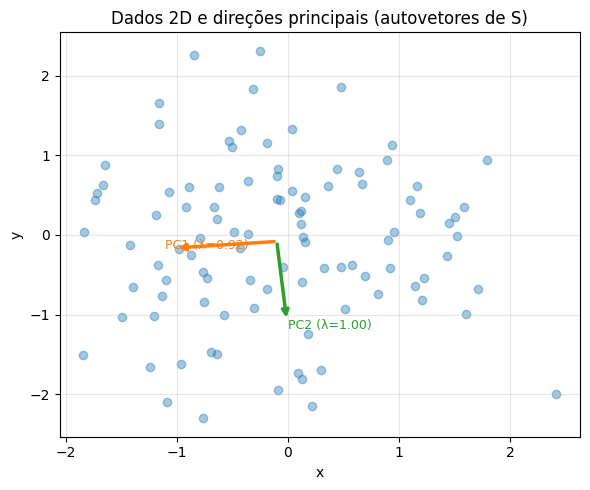

In [49]:
import matplotlib.pyplot as plt

amostra = np.random.default_rng(seed=770316)

dados2d = amostra.standard_normal((100, 2))
print(dados2d[:4])

# np.cov espera shape (features, amostras) → transpor
S = np.cov(dados2d.T)
print('\nMatriz de covariância S:\n', np.round(S, 4))

autovalores_s, autovetores_s = np.linalg.eig(S)

print('\nAutovalores :', np.round(autovalores_s, 4))
print('Autovetores :\n', np.round(autovetores_s, 4))

# Visualização
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dados2d[:, 0], dados2d[:, 1], alpha=0.4, label='Dados')
origem = dados2d.mean(axis=0)
for i, (val, vec) in enumerate(zip(autovalores_s, autovetores_s.T)):
    ax.annotate('', xy=origem + vec * val,
                xytext=origem,
                arrowprops=dict(arrowstyle='->', color=f'C{i+1}', lw=2.5))
    ax.text(*(origem + vec * val * 1.1), f'PC{i+1} (λ={val:.2f})',
            color=f'C{i+1}', fontsize=9)
ax.set_title('Dados 2D e direções principais (autovetores de S)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# Pandas – Conjunto 1

## Exercício 1
Carregar iris.csv, head, info e isna.

In [7]:
import pandas as pd

dados = pd.read_csv('iris.csv')
print('head():')
display(dados.head())

print('\ninfo()\n')
dados.info()

print('\nValores ausentes')
print(dados.isna().sum())

head():


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Valores ausentes
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64


## Exercício 2
Média e desvio-padrão do comprimento da pétala por espécie.

In [9]:
resultado = (
    dados.groupby('variety')['petal.length']
      .agg(media='mean', desvio='std')
      .round(3)
      .sort_values('media')
)

resultado

,media,desvio
variety,,
Setosa,1.462,0.174
Versicolor,4.260,0.470
Virginica,5.552,0.552


## Exercício 3
DataFrame manual: nome, idade, cidade — adicionar e remover coluna.

In [13]:
dados = pd.DataFrame({
    'nome':   ['Juliano', 'Tiago', 'Estela', 'Pedro'],
    'idade':  [24, 33, 58, 65],
    'cidade': ['SP', 'SP', 'SP', 'SP']
})

display(dados)

dados['idade_ao_quadrado'] = dados['idade'] ** 2

print('\nCom nova coluna:')
display(dados)

dados = dados.drop(columns=['idade_ao_quadrado'])
print('\nRemovendo a coluna:')
display(dados)

,nome,idade,cidade
0,Juliano,24,SP
1,Tiago,33,SP
2,Estela,58,SP
3,Pedro,65,SP



Com nova coluna:


,nome,idade,cidade,idade_ao_quadrado
0,Juliano,24,SP,576
1,Tiago,33,SP,1089
2,Estela,58,SP,3364
3,Pedro,65,SP,4225



Removendo a coluna:


,nome,idade,cidade
0,Juliano,24,SP
1,Tiago,33,SP
2,Estela,58,SP
3,Pedro,65,SP


## Exercício 4
Filtrar linhas com idade > 30.

In [15]:

filtrado = dados[dados['idade'] > 30]
display(filtrado)

print(f'\nTotal de linhas que satisfazem a condição: {len(filtrado)}')


,nome,idade,cidade
1,Tiago,33,SP
2,Estela,58,SP
3,Pedro,65,SP



Total de linhas que satisfazem a condição: 3


## Exercício 5
Notas de alunos: média por aluno, por disciplina e melhor aluno.

In [22]:
notas = pd.DataFrame({
    'Inferencia': [8.5, 5.0, 6.5],
    'Bayesiana':  [7.0, 8.5, 6.5],
    'MLG':   [9.0, 7.0, 8.0],
    'Regressão':   [6.5, 9.0, 7.5],
}, index=['Beatriz','Juliano','Aline'])

media_aluno = notas.mean(axis=1).round(2)
print('Média por aluno:')
print(media_aluno)

media_disciplina = notas.mean(axis=0).round(2)
print('\nMédia por disciplina:')
print(media_disciplina)

melhor = media_aluno.idxmax()
print(f'\nAluno com maior média: {melhor}  ({media_aluno[melhor]:.2f})')

Média por aluno:
Beatriz    7.75
Juliano    7.38
Aline      7.12
dtype: float64

Média por disciplina:
Inferencia    6.67
Bayesiana     7.33
MLG           8.00
Regressão     7.67
dtype: float64

Aluno com maior média: Beatriz  (7.75)


## Exercício 6
Selecionar petal.length e petal.width do iris e normalizar para [0,1].

In [25]:
dados = pd.read_csv('iris.csv')
petalas = dados[['petal.length', 'petal.width']].copy()

# Normalização
petalas_norm = petalas.apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
    )

print('Primeiras linhas normalizadas:')
display(petalas_norm.head())
print('\nMin por coluna:', petalas_norm.min().to_dict())
print('Max por coluna:', petalas_norm.max().to_dict())

Primeiras linhas normalizadas:


,petal.length,petal.width
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667



Min por coluna: {'petal.length': 0.0, 'petal.width': 0.0}
Max por coluna: {'petal.length': 1.0, 'petal.width': 1.0}


## Exercício 7
DataFrame de vendas: receita, agrupamento e ordenação.

In [ ]:
vendas = pd.DataFrame({
    'produto':    ['Caneta','Caderno','Caneta','Borracha','Caderno',
                   'Borracha','Caneta','Caderno','Régua','Régua'],
    'preco':      [1.50, 12.00, 1.50, 2.00, 12.00,
                   2.00, 1.50, 12.00, 3.50, 3.50],
    'quantidade': [10, 5, 8, 15, 3, 7, 12, 6, 4, 9]
})

vendas['receita'] = vendas['preco'] * vendas['quantidade']

print('DataFrame com receita:')
display(vendas)


receita_total = (
    vendas.groupby('produto')['receita']
          .sum()
          .sort_values(ascending=False)
          .rename('receita_total')
)

print('\nReceita total por produto (mais para menos):')

print(receita_total)

DataFrame com receita:


,produto,preco,quantidade,receita
0,Caneta,1.5,10,15.0
1,Caderno,12.0,5,60.0
2,Caneta,1.5,8,12.0
3,Borracha,2.0,15,30.0
4,Caderno,12.0,3,36.0
5,Borracha,2.0,7,14.0
6,Caneta,1.5,12,18.0
7,Caderno,12.0,6,72.0
8,Régua,3.5,4,14.0
9,Régua,3.5,9,31.5



Receita total por produto (mais para menos):
produto
Caderno     168.0
Régua        45.5
Caneta       45.0
Borracha     44.0
Name: receita_total, dtype: float64


## Exercício 8
Exportar apenas Setosa e verificar número de linhas ao reimportar.

In [27]:
setosa = dados[dados['variety'] == 'Setosa']
setosa.to_csv('iris_setosa.csv', index=False)
print(f'Linhas exportadas: {len(setosa)}')

setosa_re = pd.read_csv('iris_setosa.csv')
print(f'Linhas lidas de volta: {len(setosa_re)}')
print(f'Batem? {len(setosa) == len(setosa_re)}')

Linhas exportadas: 50
Linhas lidas de volta: 50
Batem? True


---
# Pandas – Conjunto 2 (iris)

## Exercício 1
Carregar, head, info e isna.

In [31]:
import pandas as pd
import numpy as np

dados = pd.read_csv('iris.csv')

print('head()')
display(dados.head())

print('\ninfo()')
dados.info()

print('\nValores ausentes:')
print(dados.isna().sum())

head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Valores ausentes:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64


## Exercício 2
Estatísticas descritivas com `describe`.

In [33]:
dados.describe().round(3)

,sepal.length,sepal.width,petal.length,petal.width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## Exercício 3
Média e desvio de petal.length por variety, ordenado pela média.

In [34]:
resumo = (
    dados.groupby('variety')['petal.length']
      .agg(media='mean', desvio='std')
      .round(3)
      .sort_values('media')
)
print(resumo)

            media  desvio
variety                  
Setosa      1.462   0.174
Versicolor  4.260   0.470
Virginica   5.552   0.552


## Exercício 4
Selecionar petal.length e petal.width e normalizar para [0,1].

In [36]:
petalas2 = dados[['petal.length', 'petal.width']].copy()

petalas2_norm = petalas2.apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
    )

(petalas2_norm.describe().round(3))

,petal.length,petal.width
count,150.000,150.000
mean,0.467,0.458
std,0.299,0.318
min,0.000,0.000
25%,0.102,0.083
50%,0.568,0.500
75%,0.695,0.708
max,1.000,1.000


## Exercício 5
Filtrar apenas Setosa com `query` e contar observações.

In [37]:
setosa_q = dados.query('variety == "Setosa"')

print('Primeiras linhas Setosa:')
display(setosa_q.head())

print(f'\nTotal de observações Setosa: {len(setosa_q)}')

Primeiras linhas Setosa:


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



Total de observações Setosa: 50


## Exercício 6
Exportar Versicolor e verificar linhas ao reimportar.

In [39]:
versicolor = dados[dados['variety'] == 'Versicolor']

versicolor.to_csv('iris_versicolor.csv', index=False)
print(f'Exportadas: {len(versicolor)} linhas')

versicolor_re = pd.read_csv('iris_versicolor.csv')
print(f'Reimportadas: {len(versicolor_re)} linhas')
print(f'Consistente? {len(versicolor) == len(versicolor_re)}')

Exportadas: 50 linhas
Reimportadas: 50 linhas
Consistente? True


## Exercício 7
Filtro com múltiplas condições e ordenação por petal.length.

In [45]:
filtrado7 = (
    dados.query(
        '`sepal.length` > 6 and variety != "Virginica"'
        )
      .sort_values('petal.length')
      .reset_index(drop=True)
)

filtrado7[:4]

,sepal.length,sepal.width,petal.length,petal.width,variety
0,6.1,2.8,4.0,1.3,Versicolor
1,6.4,2.9,4.3,1.3,Versicolor
2,6.2,2.9,4.3,1.3,Versicolor
3,6.7,3.1,4.4,1.4,Versicolor


---
# Matplotlib

## Exercício 1
Histograma de sepal.length.

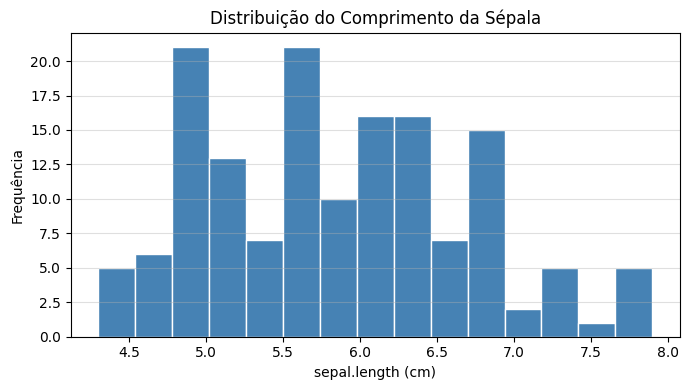

In [48]:
import matplotlib.pyplot as plt

df = pd.read_csv('iris.csv')

plt.figure(figsize=(7, 4))
plt.hist(df['sepal.length'], bins=15, color='steelblue', edgecolor='white')
plt.title('Distribuição do Comprimento da Sépala')
plt.xlabel('sepal.length (cm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

## Exercício 2
Scatter sepal.length × sepal.width, colorido por variety.

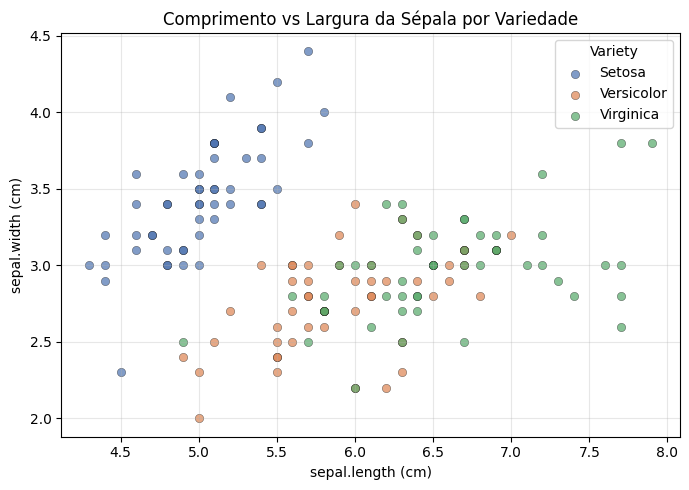

In [49]:
cores_var = {'Setosa': '#4C72B0', 'Versicolor': '#DD8452', 'Virginica': '#55A868'}

plt.figure(figsize=(7, 5))
for var, grp in df.groupby('variety'):
    plt.scatter(grp['sepal.length'], grp['sepal.width'],
                label=var, color=cores_var[var], alpha=0.7, edgecolors='k', linewidths=0.3)
plt.title('Comprimento vs Largura da Sépala por Variedade')
plt.xlabel('sepal.length (cm)')
plt.ylabel('sepal.width (cm)')
plt.legend(title='Variety')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Exercício 3
Scatter petal.length × petal.width, tamanho proporcional a sepal.length.

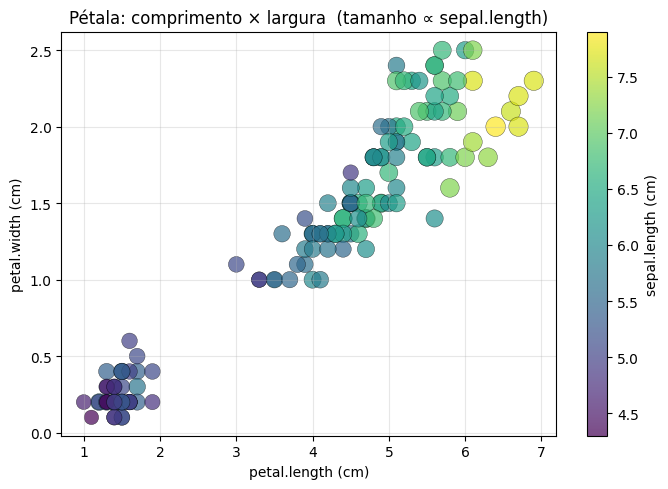

In [56]:
tamanhos = (df['sepal.length'] / df['sepal.length'].max()) * 200 

plt.figure(figsize=(7, 5))
sc = plt.scatter(df['petal.length'], df['petal.width'],
                 s=tamanhos, c=df['sepal.length'],
                 cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, label='sepal.length (cm)')
plt.title('Pétala: comprimento × largura  (tamanho ∝ sepal.length)')
plt.xlabel('petal.length (cm)')
plt.ylabel('petal.width (cm)')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Exercício 4
3 histogramas de petal.length, um por variedade, lado a lado.

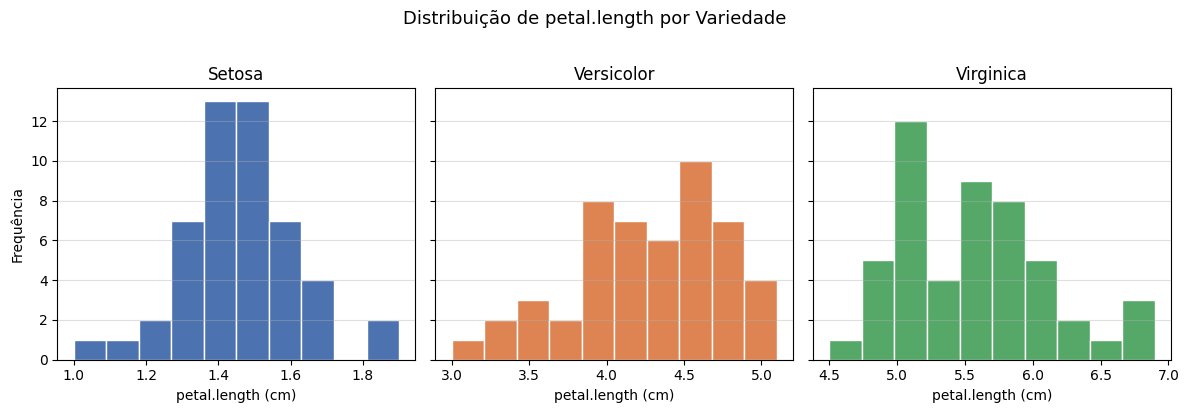

In [51]:
variedades = ['Setosa', 'Versicolor', 'Virginica']
cores4 = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, var, cor in zip(axes, variedades, cores4):
    dados_var = df[df['variety'] == var]['petal.length']
    ax.hist(dados_var, bins=10, color=cor, edgecolor='white')
    ax.set_title(var, fontsize=12)
    ax.set_xlabel('petal.length (cm)')
    ax.grid(axis='y', alpha=0.4)

axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuição de petal.length por Variedade', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## Exercício 5
Boxplots das 4 medidas.

IQRs: {'sepal.length': np.float64(1.3), 'sepal.width': np.float64(0.5), 'petal.length': np.float64(3.5), 'petal.width': np.float64(1.5)}
Maior variabilidade: petal.length  (IQR = 3.500)


C:\Users\julia\AppData\Local\Temp\ipykernel_3996\4077259356.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados_bp, labels=colunas, patch_artist=True,


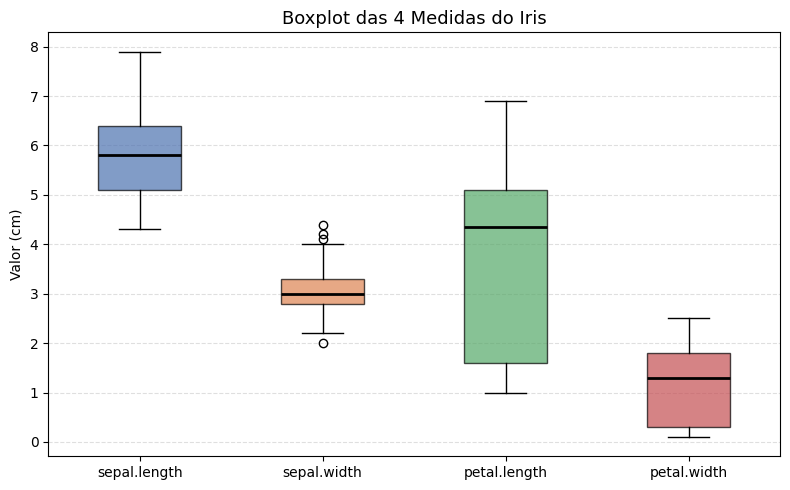

In [55]:
colunas = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
dados_bp = [df[col].values for col in colunas]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(dados_bp, labels=colunas, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
cores5 = ['#4C72B0','#DD8452','#55A868','#C44E52']
for patch, cor in zip(bp['boxes'], cores5):
    patch.set_facecolor(cor); patch.set_alpha(0.7)

ax.set_title('Boxplot das 4 Medidas do Iris', fontsize=13)
ax.set_ylabel('Valor (cm)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

iqrs = {col: df[col].quantile(0.75) - df[col].quantile(0.25) for col in colunas}
mais_variavel = max(iqrs, key=iqrs.get)
print('IQRs:', {k: round(v,3) for k,v in iqrs.items()})
print(f'Maior variabilidade: {mais_variavel}  (IQR = {iqrs[mais_variavel]:.3f})')

plt.tight_layout(); plt.show()

## Exercício 6
Gráfico de barras das médias por variedade.

            sepal.length  sepal.width  petal.length  petal.width
variety                                                         
Setosa              5.01         3.43          1.46         0.25
Versicolor          5.94         2.77          4.26         1.33
Virginica           6.59         2.97          5.55         2.03


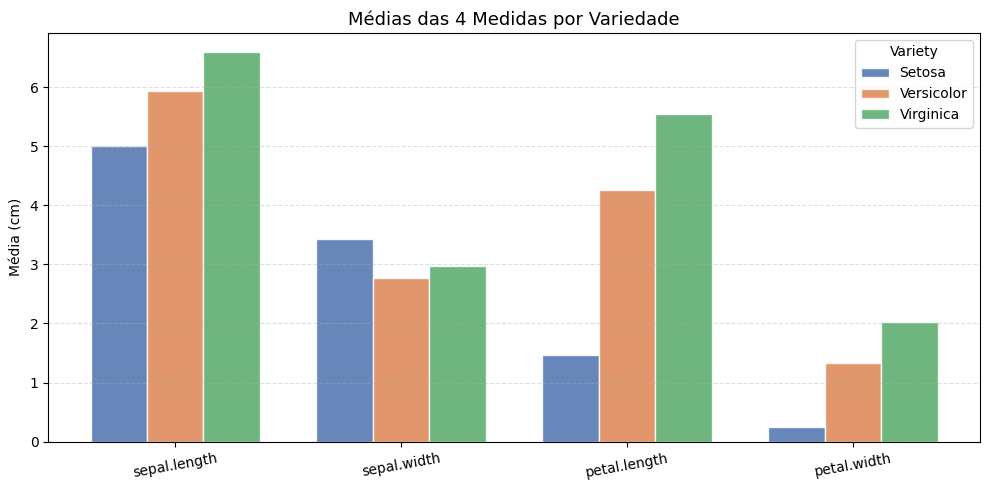

In [53]:
medias_grupo = df.groupby('variety')[colunas].mean()
print(medias_grupo.round(2))

x   = np.arange(len(colunas))
w   = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, (var, row) in enumerate(medias_grupo.iterrows()):
    ax.bar(x + i*w, row.values, w, label=var,
           color=list(cores_var.values())[i], alpha=0.85, edgecolor='white')

ax.set_title('Médias das 4 Medidas por Variedade', fontsize=13)
ax.set_xticks(x + w)
ax.set_xticklabels(colunas, rotation=10)
ax.set_ylabel('Média (cm)')
ax.legend(title='Variety')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## Exercício 7
Scatter 3D: sepal.length × sepal.width × petal.length.

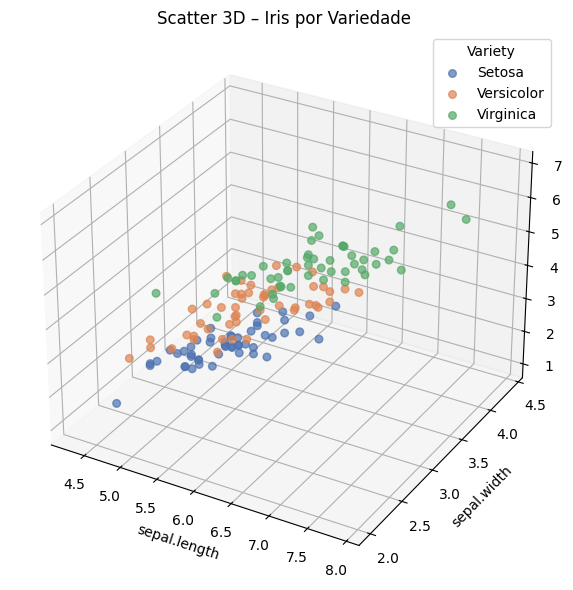

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 6))
ax3 = fig.add_subplot(111, projection='3d')

for var, grp in df.groupby('variety'):
    ax3.scatter(grp['sepal.length'], grp['sepal.width'], grp['petal.length'],
                label=var, color=cores_var[var], alpha=0.7, s=30)

ax3.set_xlabel('sepal.length'); ax3.set_ylabel('sepal.width'); ax3.set_zlabel('petal.length')
ax3.set_title('Scatter 3D – Iris por Variedade', fontsize=12)
ax3.legend(title='Variety')
plt.tight_layout(); plt.show()